In [3]:
import jax 
import jax.numpy as jnp

from probjax.core.jaxpr_propagation.propagate import *
from probjax.core.interpreters.inverse import InverseProcessingRule, inverse_cost_fn

In [4]:
def propagate(
    jaxpr: Jaxpr,
    consts: Sequence[Array],
    invars: Sequence[Var],
    inputs: Sequence[Array],
    outvars: Sequence[Var],
    process_eqn: ProcessingRule
    | Callable[
        [JaxprEqn, Sequence[Optional[Array]], Sequence[Optional[Array]]],
        Tuple[Sequence[Var], Any],
    ] = ForwardProcessingRule(),
    cost_fn: Callable = naive_cost_fn,
    process_all_eqns: bool = False,
) -> Sequence[Optional[Array]]:
    """This implements a general propagation algorithm for JaxPr.

    Args:
        jaxpr (Jaxpr): Jaxpr object.
        consts (Sequence[Array]): Constants.
        invars (Sequence[Var]): Input variables.
        inputs (Sequence[Array]): Input data.
        outvars (Sequence[Var]): Output variables.
        process_eqn (Callable[ [JaxprEqn, Sequence[Optional[Array]], Sequence[Optional[Array]]], Tuple[Sequence[Var], Sequence[Array]], ]): Function that processes the equation.
        cost_fn (Callable, optional): Cost function to prioritize the evaluation order!. Defaults to naive_cost_fn.

    Returns:
        Sequence[Optional[Array]]: _description_
    """

    # Set up environment
    env = Environment()

    G = construct_jaxpr_graph(jaxpr)

    map(env.write, jaxpr.constvars, consts)
    map(env.write, invars, inputs)

    # Set up equations
    eqn_env = EqnEnvironment(G, env, jaxpr.eqns, cost_fn)

    while not eqn_env.is_empty():
        
        print(list(env.items()))
        print(eqn_env.eqn_queue)
        eqn = eqn_env.pop()  # Equation to process
        print(eqn.primitive)

        # Read known invars and outvars
        known_invars = map(env.read, eqn.invars)
        known_outvars = map(env.read, eqn.outvars)

        if eqn.primitive is pjit_p or eqn.primitive is custom_jvp_call_p:

            # Extract subjaxpr
            if eqn.primitive is pjit_p:
                closed_sub_jaxpr = eqn.params["jaxpr"]
            else:
                closed_sub_jaxpr = eqn.params["call_jaxpr"]
            sub_jaxpr = closed_sub_jaxpr.jaxpr
            sub_consts = closed_sub_jaxpr.consts

            sub_invars = []
            sub_invar_vals = []
            sub_outvars = []
            for v, val in zip(
                sub_jaxpr.invars + sub_jaxpr.outvars, known_invars + known_outvars
            ):
                if val is None:
                    sub_outvars.append(v)
                else:
                    sub_invars.append(v)
                    sub_invar_vals.append(val)

            output_vals = propagate(
                sub_jaxpr,
                sub_consts,
                sub_invars,
                sub_invar_vals,
                sub_outvars,
                process_eqn=process_eqn,
                cost_fn=cost_fn,
                process_all_eqns=process_all_eqns,
            )
            ouput_vars = []
            for v, val in zip(eqn.invars + eqn.outvars, known_invars + known_outvars):
                if val is None:
                    ouput_vars.append(v)

            process_eqn(eqn, known_invars, ouput_vars)

        else:
            # This processes the computation
            ouput_vars, output_vals = process_eqn(eqn, known_invars, known_outvars)

        # Write outvars
        map(env.write, ouput_vars, output_vals)

        # Update reachable equations
        for v in ouput_vars:
            if not isinstance(v, Literal):
                eqns_index = G[v]
            map(eqn_env.write, eqns_index)

        print(list(env.items()))
        print(eqn_env.eqn_queue)

        if not process_all_eqns and all(map(env.known, outvars)):
            break

    # Gather target values
    out = map(env.read, outvars)

    return out


In [5]:
from probjax.core.jaxpr_propagation.graph import JaxprGraph

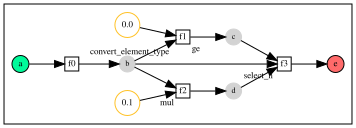

In [7]:
def f(x):
    x = x.astype(jnp.float32)
    return jax.lax.select_n(x >= 0, x*0.1, x)

# def f(x):
#     return jnp.where(x >= 0, x*0.1, x)
x = jnp.array([-1., 0., 1.])
y = f(x)
jaxpr = jax.make_jaxpr(f)(jnp.array([-1, 0, 1]))
g = JaxprGraph(jaxpr.jaxpr)

g

In [8]:
x

Array([-1.,  0.,  1.], dtype=float32)

In [9]:
y

Array([-0.1,  0. ,  1. ], dtype=float32)

In [10]:
which1, other1 = propagate(jaxpr.jaxpr, jaxpr.consts, [jaxpr.eqns[-1].invars[2]], [jnp.array([-0.1, 0, 1.])], [jaxpr.eqns[-1].invars[0], jaxpr.eqns[-1].invars[1]], process_eqn=InverseProcessingRule(), cost_fn=inverse_cost_fn)

[(b, Array([-0.1,  0. ,  1. ], dtype=float32))]
[(1, 0), (0, 0.5), (2, 0), (3, inf)]
ge
[(b, Array([-0.1,  0. ,  1. ], dtype=float32)), (c, Array([False,  True,  True], dtype=bool))]
[(2, 0), (0, 0.5), (3, inf)]
[(b, Array([-0.1,  0. ,  1. ], dtype=float32)), (c, Array([False,  True,  True], dtype=bool))]
[(2, 0), (0, 0.5), (3, inf)]
mul
[(b, Array([-0.1,  0. ,  1. ], dtype=float32)), (c, Array([False,  True,  True], dtype=bool)), (d, Array([-0.01,  0.  ,  0.1 ], dtype=float32))]
[(3, 0), (0, 0.5)]


In [11]:
which2, other2 = propagate(jaxpr.jaxpr, jaxpr.consts, [jaxpr.eqns[-1].invars[1]], [jnp.array([-.1, 0, 1.])], [jaxpr.eqns[-1].invars[0], jaxpr.eqns[-1].invars[2]], process_eqn=InverseProcessingRule(), cost_fn=inverse_cost_fn)

[(d, Array([-0.1,  0. ,  1. ], dtype=float32))]
[(2, 0.5), (3, inf)]
mul
[(d, Array([-0.1,  0. ,  1. ], dtype=float32)), (b, Array([-1.,  0., 10.], dtype=float32))]
[(1, 0), (3, inf), (0, 0.5)]
[(d, Array([-0.1,  0. ,  1. ], dtype=float32)), (b, Array([-1.,  0., 10.], dtype=float32))]
[(1, 0), (3, inf), (0, 0.5)]
ge
[(d, Array([-0.1,  0. ,  1. ], dtype=float32)), (b, Array([-1.,  0., 10.], dtype=float32)), (c, Array([False,  True,  True], dtype=bool))]
[(3, 0), (0, 0.5)]


In [26]:
assert jnp.all(which1 == which2)

y * (1 - which1) + which1 * other1

Array([-0.1,  0. ,  0.1], dtype=float32)

In [28]:
y * which1 + (1-which1) * other2

Array([-1.,  0.,  1.], dtype=float32)

In [20]:
y

Array([-0.1,  0. ,  1. ], dtype=float32)

In [17]:
y

Array([-0.1,  0. ,  1. ], dtype=float32)

In [23]:
which1

Array([False,  True,  True], dtype=bool)

In [5]:
from copy import deepcopy

def parental_subjaxpr(closed_jaxpr, start_vars, stop_vars):
    # Extract subjaxpr
    jaxpr = closed_jaxpr.jaxpr
    consts = closed_jaxpr.consts

    invars = start_vars
    outvars = stop_vars

    sub_eqns = []
    intermediate_vars = []
    for eqn in closed_jaxpr.eqns:
        if any([(v in start_vars) or (v in intermediate_vars) for v in eqn.invars]):
            intermediate_vars.extend(eqn.outvars)
            sub_eqns.append(eqn)
        
        if any([v in stop_vars for v in eqn.outvars]):
            break

    new_jaxpr = Jaxpr(jaxpr.constvars, invars, outvars, sub_eqns)
    new_consts = [consts[i] for i in new_jaxpr.constvars]
    return jax.core.ClosedJaxpr(new_jaxpr, new_consts)

In [6]:
jaxpr.eqns[-1].invars[0].count

2

In [18]:
jaxpr

{ lambda ; a:i32[3]. let
    b:f32[3] = convert_element_type[new_dtype=int32 weak_type=False] a
    c:bool[3] = ge b 0.0
    d:f32[3] = mul b 0.10000000149011612
    e:f32[3] = select_n c d b
  in (e,) }

In [17]:
sub_jaxpr1 = parental_subjaxpr(jaxpr, [jaxpr.eqns[-1].invars[1], jaxpr.eqns[-1].invars[2]], [jaxpr.eqns[-1].invars[0]])

sub_jaxpr1

{ lambda ; a:f32[3] b:f32[3]. let c:bool[3] = ge b 0.0 in (c,) }

In [7]:
sub_jaxpr1 = parental_subjaxpr(jaxpr, [jaxpr.eqns[-1].invars[0]], jaxpr.eqns[-1].outvars)
sub_jaxpr2 = parental_subjaxpr(jaxpr, [jaxpr.eqns[-1].invars[1]], jaxpr.eqns[-1].outvars)
sub_jaxpr3 = parental_subjaxpr(jaxpr, [jaxpr.eqns[-1].invars[2]], jaxpr.eqns[-1].outvars)

test_fn = jax.core.jaxpr_as_fun(sub_jaxpr3)

In [8]:
test_fn(y)

[Array([-0.01,  0.  ,  1.  ], dtype=float32)]

In [9]:
construct_jaxpr_graph(jaxpr.jaxpr)

{a: [0], b: [0, 1, 2, 3], c: [1, 3], d: [2, 3], e: [3]}

In [13]:
propagate(jaxpr.jaxpr, jaxpr.consts, jaxpr.jaxpr.outvars, [y], jaxpr.jaxpr.invars, process_eqn=InverseProcessingRule(), cost_fn=inverse_cost_fn, process_all_eqns=True)

[(e, Array([-0.1,  0. ,  1. ], dtype=float32))]
[(3, 0.5)]
select_n
a:f32[3] = select_n b c d
[None, None, None] [Array([-0.1,  0. ,  1. ], dtype=float32)]
[(e, Array([-0.1,  0. ,  1. ], dtype=float32)), (c, None), (d, Array([-0.1,  0. ,  1. ], dtype=float32)), (b, Array([-0.1,  0. ,  1. ], dtype=float32))]
[(1, 0), (2, 0), (0, 0.5)]
[(e, Array([-0.1,  0. ,  1. ], dtype=float32)), (c, None), (d, Array([-0.1,  0. ,  1. ], dtype=float32)), (b, Array([-0.1,  0. ,  1. ], dtype=float32))]
[(1, 0), (2, 0), (0, 0.5)]
ge
[(e, Array([-0.1,  0. ,  1. ], dtype=float32)), (c, Array([False,  True,  True], dtype=bool)), (d, Array([-0.1,  0. ,  1. ], dtype=float32)), (b, Array([-0.1,  0. ,  1. ], dtype=float32))]
[(2, 0), (0, 0.5)]
[(e, Array([-0.1,  0. ,  1. ], dtype=float32)), (c, Array([False,  True,  True], dtype=bool)), (d, Array([-0.1,  0. ,  1. ], dtype=float32)), (b, Array([-0.1,  0. ,  1. ], dtype=float32))]
[(2, 0), (0, 0.5)]
mul
[(e, Array([-0.1,  0. ,  1. ], dtype=float32)), (c, Array([Fa

[Array([0, 0, 1], dtype=int32)]

In [7]:
jaxpr

{ lambda ; a:i32[3]. let
    b:bool[3] = gt a 0
    c:i32[3] = pjit[
      jaxpr={ lambda ; d:bool[3] e:i32[3] f:i32[]. let
          g:i32[] = convert_element_type[new_dtype=int32 weak_type=False] f
          h:i32[3] = broadcast_in_dim[broadcast_dimensions=() shape=(3,)] g
          i:i32[3] = select_n d h e
        in (i,) }
      name=_where
    ] b a 0
  in (c,) }